## K-Means Clustering

### Assignment 1 (2 scores):

- Generate a toy dataset having $600$ data points, $200$ points of them following the Gaussian distribution $\mathcal{N}((2, 2), \Sigma)$, $200$ points of them following the Gaussian distribution $\mathcal{N}((8, 3), \Sigma)$, and $200$ points of them following the Gaussian distribution $\mathcal{N}((3, 6), \Sigma)$ where $\Sigma =
\left(\begin{array}{cc}
    1 & 0 \\
    0 & 1
\end{array}\right)
$.
- Use Numpy only to implement the K-means method for finding three clusters from the toy dataset.
- Train this K-means with EM method.
- Give comments on the effect of intializing centroids randomly to the overall performance of K-means.

In [11]:
import numpy as np
import matplotlib.pyplot as plt

In [12]:
# 1. Tạo dữ liệu
np.random.seed(42)  # để kết quả giống nhau mỗi lần chạy

mean1 = [2, 2]
mean2 = [8, 3]
mean3 = [3, 6]
cov = [[1, 0], [0, 1]]  # Σ = I

cluster1 = np.random.multivariate_normal(mean1, cov, 200)
cluster2 = np.random.multivariate_normal(mean2, cov, 200)
cluster3 = np.random.multivariate_normal(mean3, cov, 200)

data1 = np.vstack((cluster1, cluster2, cluster3))  # shape (600, 2)
labels_true1 = np.array([0]*200 + [1]*200 + [2]*200)

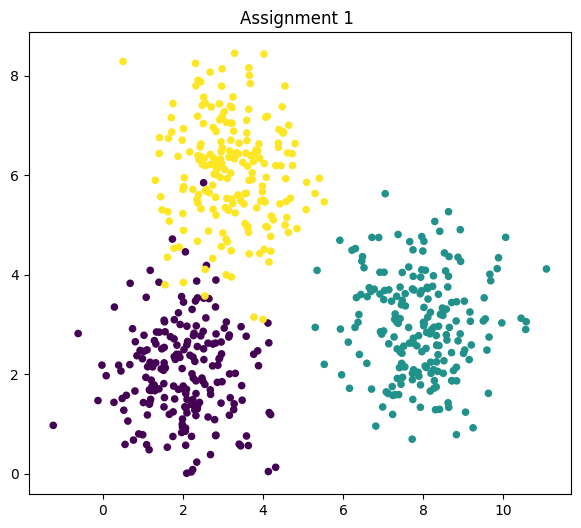

In [13]:
# Vẽ dữ liệu
plt.figure(figsize=(7,6))
plt.scatter(data1[:,0], data1[:,1], c=labels_true1, s=20, cmap='viridis')
plt.title('Assignment 1 ')
plt.show()

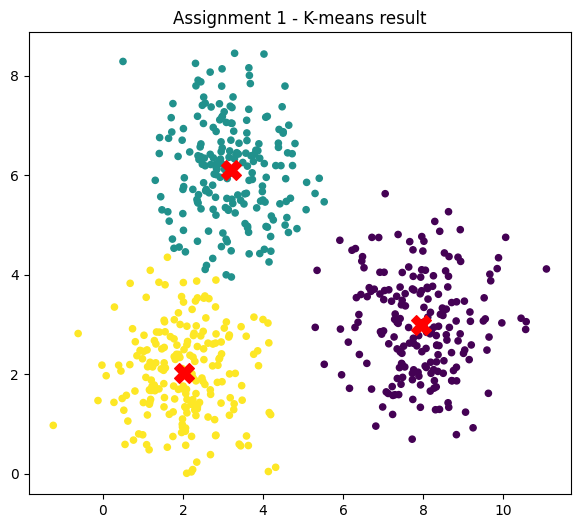

In [14]:
def kmeans_numpy(X, k=3, max_iters=100, n_init=10):
    best_inertia = np.inf
    best_centroids = None
    best_labels = None

    for _ in range(n_init):  # chạy nhiều lần khởi tạo ngẫu nhiên
        # Khởi tạo ngẫu nhiên centroids
        idx = np.random.choice(len(X), k, replace=False)
        centroids = X[idx]

        for iter in range(max_iters):
            # Bước 1: Gán nhãn (tính khoảng cách Euclidean)
            distances = np.sqrt(((X - centroids[:, np.newaxis])**2).sum(axis=2))
            labels = np.argmin(distances, axis=0)

            # Bước 2: Cập nhật centroids
            new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(k)])

            # Nếu centroids không thay đổi nữa → hội tụ
            if np.all(centroids == new_centroids):
                break
            centroids = new_centroids

        # Tính inertia (tổng bình phương khoảng cách đến centroid gần nhất)
        distances = np.sqrt(((X - centroids[labels])**2).sum(axis=1))
        inertia = distances.sum()

        if inertia < best_inertia:
            best_inertia = inertia
            best_centroids = centroids
            best_labels = labels

    return best_labels, best_centroids, best_inertia

labels_pred1, centroids1, inertia1 = kmeans_numpy(data1, k=3, n_init=20)

plt.figure(figsize=(7,6))
plt.scatter(data1[:,0], data1[:,1], c=labels_pred1, s=20, cmap='viridis')
plt.scatter(centroids1[:,0], centroids1[:,1], c='red', s=200, marker='X')
plt.title('Assignment 1 - K-means result')
plt.show()

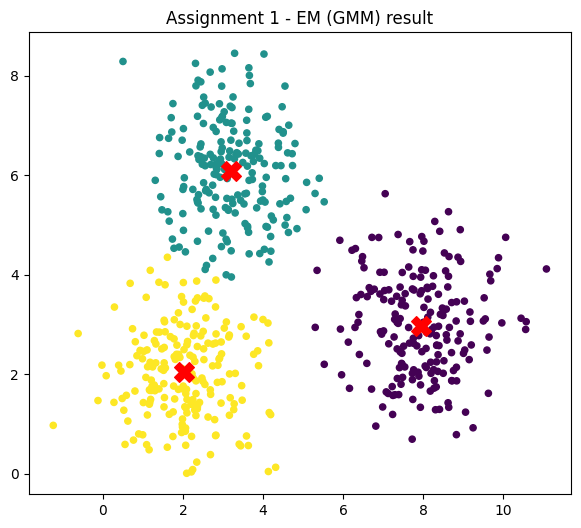

In [15]:
# 3. Huấn luyện bằng EM (tức là Gaussian Mixture Model)
from sklearn.mixture import GaussianMixture

gmm1 = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
gmm1.fit(data1)
labels_em1 = gmm1.predict(data1)

plt.figure(figsize=(7,6))
plt.scatter(data1[:,0], data1[:,1], c=labels_em1, s=20, cmap='viridis')
plt.scatter(gmm1.means_[:,0], gmm1.means_[:,1], c='red', s=200, marker='X')
plt.title('Assignment 1 - EM (GMM) result')
plt.show()

### Assignment 2 (2 scores):
- Generate a toy dataset having $50$ points following the Gaussian distribution $\mathcal{N}((2, 2), \Sigma)$, $20$ points of them following the Gaussian distribution $\mathcal{N}((8, 3), \Sigma)$, and $1000$ points of them following the Gaussian distribution $\mathcal{N}((3, 6), \Sigma)$ where $\Sigma =
\left(\begin{array}{cc}
    1 & 0 \\
    0 & 1
\end{array}\right)
$.
- Use Numpy only to implement the K-means method for finding three clusters from the toy dataset.
- Train this K-means with EM method.
- Give comments on the effect of different sizes among clusters to the performance of K-means.

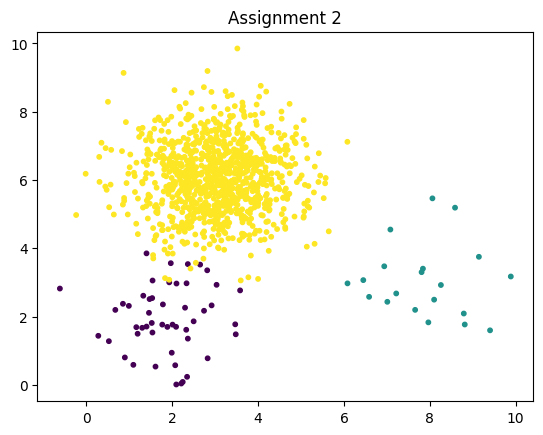

In [16]:
np.random.seed(42)

clusterA = np.random.multivariate_normal([2,2], cov, 50)
clusterB = np.random.multivariate_normal([8,3], cov, 20)
clusterC = np.random.multivariate_normal([3,6], cov, 1000)

data2 = np.vstack((clusterA, clusterB, clusterC))
labels_true2 = np.array([0]*50 + [1]*20 + [2]*1000)

plt.scatter(data2[:,0], data2[:,1], c=labels_true2, s=10, cmap='viridis')
plt.title('Assignment 2')
plt.show()

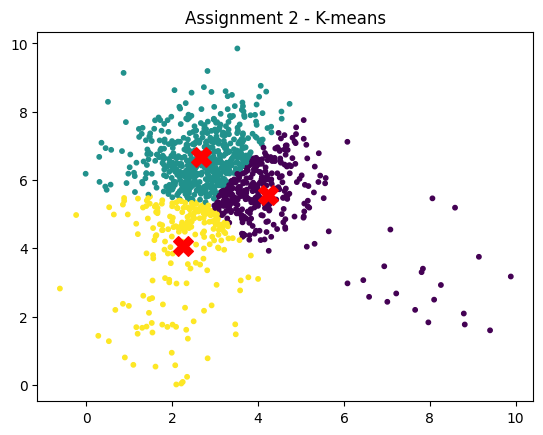

In [17]:
labels_pred2, centroids2, _ = kmeans_numpy(data2, k=3, n_init=30)

plt.scatter(data2[:,0], data2[:,1], c=labels_pred2, s=10, cmap='viridis')
plt.scatter(centroids2[:,0], centroids2[:,1], c='red', s=200, marker='X')
plt.title('Assignment 2 - K-means')
plt.show()

### Assignment 3 (2 scores):

- Generate a toy dataset having $600$ data points, $200$ points of them following the Gaussian distribution $\mathcal{N}((2, 2), \Sigma_1)$, $200$ points of them following the Gaussian distribution $\mathcal{N}((8, 3), \Sigma_1)$, and $200$ points of them following the Gaussian distribution $\mathcal{N}((3, 6), \Sigma_2)$ where

$$
    \Sigma_1 =
    \left(\begin{array}{cc}
        1 & 0 \\
        0 & 1
    \end{array}\right)
$$

and

$$
\Sigma_2 =
    \left(\begin{array}{cc}
        10 & 0 \\
        0 & 1
    \end{array}\right)
$$.

- Use Numpy only to implement the K-means method for finding three clusters from the toy dataset.
- Train this K-means with EM method.
- Give comments on the effect of distribution $\mathcal{N}((3, 6), \Sigma_2)$ to the performance of K-means.

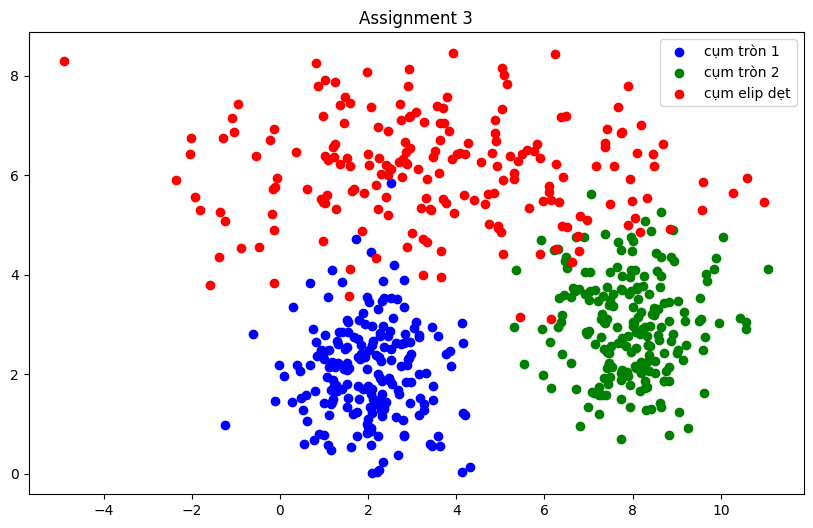

In [18]:
np.random.seed(42)

cov1 = [[1, 0], [0, 1]]        # tròn
cov2 = [[10, 0], [0, 1]]       # elip dẹt ngang, variance x = 10

cluster1 = np.random.multivariate_normal([2,2], cov1, 200)
cluster2 = np.random.multivariate_normal([8,3], cov1, 200)
cluster3 = np.random.multivariate_normal([3,6], cov2, 200)

data3 = np.vstack((cluster1, cluster2, cluster3))

plt.figure(figsize=(10,6))
plt.scatter(data3[:200,0], data3[:200,1], c='blue', label='cụm tròn 1')
plt.scatter(data3[200:400,0], data3[200:400,1], c='green', label='cụm tròn 2')
plt.scatter(data3[400:,0], data3[400:,1], c='red', label='cụm elip dẹt')
plt.legend()
plt.title('Assignment 3')
plt.show()

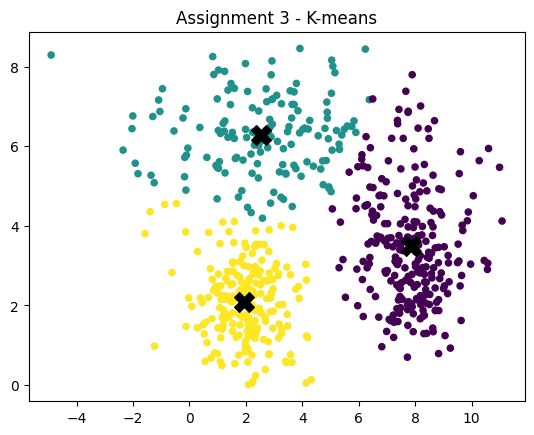

In [19]:
# Chạy K-means
labels_pred3, centroids3, _ = kmeans_numpy(data3, k=3, n_init=30)

plt.scatter(data3[:,0], data3[:,1], c=labels_pred3, s=20, cmap='viridis')
plt.scatter(centroids3[:,0], centroids3[:,1], c='black', s=200, marker='X')
plt.title('Assignment 3 - K-means')
plt.show()

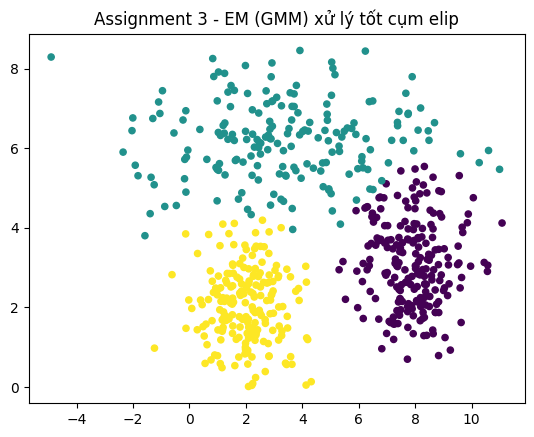

In [20]:
# Chạy EM (GMM)
gmm3 = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
gmm3.fit(data3)
labels_em3 = gmm3.predict(data3)

plt.scatter(data3[:,0], data3[:,1], c=labels_em3, s=20, cmap='viridis')
plt.title('Assignment 3 - EM (GMM) xử lý tốt cụm elip')
plt.show()

## Gaussian Mixture Model

### Assignment 1 (2 scores):
- Use Numpy only to implement the Gaussian Mixture Model.
- Train Gaussian Mixture Model with EM method.

### Assignment 2 (2 scores):

Use the Gaussian Mixture Model to filter out background of a given image.